In [1]:
import pandas as pd
import joblib

# Load clean dataset
df = pd.read_csv("../data/news_dataset_clean.csv")

# Remove empty rows again (safety)
df = df.dropna(subset=["clean_text"])
df = df[df["clean_text"].str.strip() != ""]

X = df["clean_text"]
y = df["label"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Load vectorizer
vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [2]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report (Naive Bayes):\n", classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.9472554777501694

Classification Report (Naive Bayes):
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      4537
           1       0.95      0.94      0.95      4317

    accuracy                           0.95      8854
   macro avg       0.95      0.95      0.95      8854
weighted avg       0.95      0.95      0.95      8854



In [3]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report (Logistic Regression):\n", classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.991077479105489

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4537
           1       0.99      0.99      0.99      4317

    accuracy                           0.99      8854
   macro avg       0.99      0.99      0.99      8854
weighted avg       0.99      0.99      0.99      8854



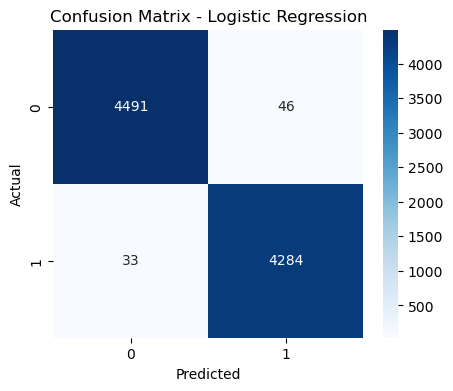

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [5]:
joblib.dump(lr_model, "../models/fake_news_model.pkl")
print("Best model saved successfully!")


Best model saved successfully!
